# Cvičení 1: Výrobní plán a grafické řešení

Řešení.

Tento notebook obsahuje všechna potřebná data. Otevřete jej v Jupyteru nebo Google Colabu. Používáme Python 3.12 nebo novější a knihovny PuLP, NumPy a Matplotlib.

Pokud knihovny ještě nemáte, vložte před první buňku novou kódovou buňku a spusťte v ní:

```python
%pip install pulp==3.3.2 numpy matplotlib
```

Data v tomto sešitu jsou modelová.

In [1]:
import pulp
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({'figure.figsize': (6, 4), 'font.size': 11})

Buňky spouštějte shora dolů pomocí Shift+Enter. V zadání doplňujte místa označená komentářem. Matematický model a graf si nejprve zkuste napsat a nakreslit na papír; potom svůj postup porovnejte s notebookem s řešením.

## Zadání
Výrobna plánuje výrobu dvou produktů na jedno období. Rozhodujeme,
kolik tun produktu 1 ($x$) a kolik tun produktu 2 ($y$) vyrobíme.
Množství jsou nezáporná a mohou být i neceločíselná, například 1,5 tuny.

**Hledáme výrobní plán s nejvyšším celkovým ziskem za dané období.**
Oba produkty přitom společně využívají tentýž stroj a tutéž surovinu:
k dispozici máme nejvýše **6 hodin stroje a 4 tuny suroviny**.
Předpokládáme, že vše, co vyrobíme, také prodáme.

Tabulka uvádí příspěvek k zisku a spotřebu zdrojů **na jednu tunu**
každého produktu. V příspěvku k zisku jsou již odečteny náklady
připadající na tuto tunu; příspěvky z obou produktů se sčítají.

| Veličina na tunu | Produkt 1 | Produkt 2 |
|---|---:|---:|
| Příspěvek k zisku [tis. Kč/t] | 3 | 2 |
| Čas stroje [h/t] | 2 | 1 |
| Surovina [t/t] | 1 | 1 |

Například jedna tuna produktu 1 přinese 3 tisíce Kč, zabere 2 hodiny
stroje a spotřebuje 1 tunu suroviny. Při větší výrobě se všechny tyto
hodnoty úměrně násobí vyráběným množstvím.

1. Vyjádřete celkový zisk pomocí $x,y$ a napište model jeho maximalizace včetně omezení a oborů proměnných.
2. Najděte optimum graficky a pomocí řešiče. Ověřte spotřeby a zisk.
3. Přidejte objednávku alespoň jedné tuny produktu 2 a porovnejte výsledek.

## Model v PuLP
Doplňte omezení na surovinu. Proměnné jsou spojité a nezáporné.

In [2]:
# Maximalizujeme zisk. x a y jsou vyrobená množství v tunách.
model = pulp.LpProblem("Vyrobni_plan", pulp.LpMaximize)
x = pulp.LpVariable("x", lowBound=0)
y = pulp.LpVariable("y", lowBound=0)

# První přidaný výraz je účelová funkce, další řádky jsou omezení.
model += 3*x + 2*y, "zisk"
model += 2*x + y <= 6, "stroj"

## Řešení
$$\max 3x+2y\quad\text{při}\quad
2x+y\le6,\quad x+y\le4,\quad x,y\ge0.$$
Proměnné jsou v tunách a hodnota cíle v tisících Kč.

In [3]:
# Oba produkty dohromady spotřebují nejvýše 4 tuny suroviny.
model += x + y <= 4, "surovina"
model.solve(pulp.PULP_CBC_CMD(msg=False))
print("Stav:", pulp.LpStatus[model.status])

# Hodnoty proměnných čteme až po nalezení optima.
if model.status != pulp.LpStatusOptimal:
    raise RuntimeError("Řešič nenašel optimální řešení.")
x_opt = x.value()
y_opt = y.value()

# Dosadíme výsledek do původních podmínek a přepočítáme zisk.
zisk = 3*x_opt + 2*y_opt
print(f"x = {x_opt:g} t, y = {y_opt:g} t, zisk = {zisk:g} tis. Kč")
print("Stroj [h]:", 2*x_opt + y_opt, "/ 6")
print("Surovina [t]:", x_opt + y_opt, "/ 4")

Stav: Optimal
x = 2 t, y = 2 t, zisk = 10 tis. Kč
Stroj [h]: 6.0 / 6
Surovina [t]: 4.0 / 4


## Grafická kontrola
Nakreslete obě hraniční přímky, přípustnou oblast a přímku konstantního zisku.

Vrcholy a zisk:
(0, 0): 0 tis. Kč
(3, 0): 9 tis. Kč
(2, 2): 10 tis. Kč
(0, 4): 8 tis. Kč


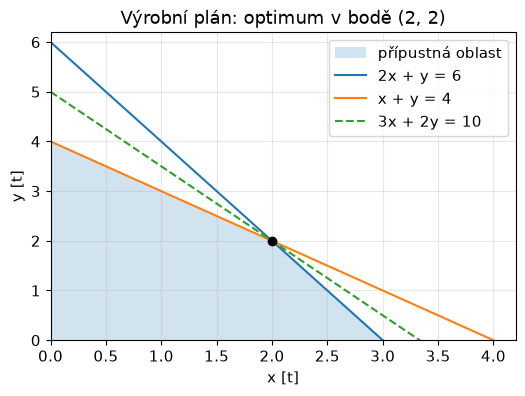

In [4]:
# Vrcholy získáme z průsečíků hraničních přímek a souřadnicových os.
vrcholy = np.array([[0, 0], [3, 0], [2, 2], [0, 4]])
print("Vrcholy a zisk:")
for x_vrchol, y_vrchol in vrcholy:
    print(f"({x_vrchol}, {y_vrchol}): {3*x_vrchol + 2*y_vrchol} tis. Kč")

# Z každé rovnice vyjádříme y a vykreslíme jej pro zvolené hodnoty x.
osa_x = np.linspace(0, 4.2, 200)
fig, ax = plt.subplots(figsize=(6, 4))
ax.fill(vrcholy[:, 0], vrcholy[:, 1], alpha=0.2, label="přípustná oblast")
ax.plot(osa_x, 6 - 2*osa_x, label="2x + y = 6")
ax.plot(osa_x, 4 - osa_x, label="x + y = 4")
ax.plot(osa_x, (10 - 3*osa_x)/2, "--", label="3x + 2y = 10")
ax.scatter([2], [2], color="black", zorder=5)
ax.set(xlim=(0, 4.2), ylim=(0, 6.2), xlabel="x [t]", ylabel="y [t]")
ax.set_title("Výrobní plán: optimum v bodě (2, 2)")
ax.grid(alpha=0.3)
ax.legend()
plt.show()

Plán $(2,2)$ spotřebuje $2\cdot2+2=6$ hodin stroje a $2+2=4$ tuny suroviny. Zisk je $3\cdot2+2\cdot2=10$ tisíc Kč.
Sečtením obou kapacitních omezení dostaneme $3x+2y\le10$. Žádný přípustný plán tedy nemá vyšší zisk a náš plán této meze dosahuje.

## Objednávka
Zapište požadavek alespoň jedné tuny produktu 2 a model znovu vyřešte.

In [5]:
# Nové omezení přidáme ke stávajícímu modelu.
model += y >= 1, "objednavka"
model.solve(pulp.PULP_CBC_CMD(msg=False))
print("Stav:", pulp.LpStatus[model.status])
if model.status == pulp.LpStatusOptimal:
    print("Plán:", x.value(), y.value(), "t")
    print("Zisk:", pulp.value(model.objective), "tis. Kč")

Stav: Optimal
Plán: 2.0 2.0 t
Zisk: 10.0 tis. Kč


Plán `(2,2)` již objednávku splňoval. Optimum se nezmění a zisk zůstává 10 tisíc Kč.